# Quadratic forms, entropy, KL — closed-form Gaussian quantities

Why is variational inference with Gaussian distributions *so much faster* than VI with anything else? Because every quantity you need — log-density, entropy, score, KL, expected log-likelihood, mutual information — has a **closed form** in terms of $\boldsymbol{\mu}$, $\boldsymbol{\Sigma}$, and a Cholesky factor. No Monte Carlo, no quadrature, just linear algebra. This notebook is the catalog.

**What you'll learn**

1. The quadratic form $\tfrac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^\top\boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})$ — the workhorse, computed via Cholesky and triangular solves.
2. Score $\nabla_{\mathbf{x}}\log p(\mathbf{x})$ — fundamental for HMC, Langevin, diffusion, score matching.
3. Entropy and cross-entropy, and the identity that links them to KL.
4. KL between two Gaussians — full closed form, asymmetry, mode-covering vs mode-seeking.
5. Expected log-likelihood under a Gaussian — the data-fit term of every Gaussian ELBO.
6. Mutual information between sub-blocks — closed-form information geometry of an MVN.
7. A one-step ELBO putting the closed-form KL and ELL together.

:::{important}
This is the **why** of Gaussian variational inference. Almost every cost / loss / regulariser you'll encounter in subsequent notebooks (SVGP, Bayesian NNs, Kalman filtering with information loss, natural gradients) is a sum of the scalars derived here.
:::

:::{note}
Linear-algebra ops use [`einx`](https://github.com/fferflo/einx) per the convention from notebooks 0.1–0.2. Each quantity below follows the same four-part structure: an *ELI5* one-liner, a *formal* description, the *continuous-form* equation(s), the *numerical recipe* we actually run, and a final note on *interpretation and where it shows up* downstream.
:::

In [1]:
from __future__ import annotations

import warnings

warnings.filterwarnings("ignore", message=r".*IProgress.*")

import einx
import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import numpy as np
from gaussx import (
    MultivariateNormal,
    add_jitter,
    cholesky,
    dist_kl_divergence,
    gaussian_entropy,
    gaussian_expected_log_lik,
    gaussian_log_prob,
    kl_standard_normal,
    quadratic_form,
    solve,
)

jax.config.update("jax_enable_x64", True)
KEY = jax.random.PRNGKey(0)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.3,
})

def psd_op(M):
    return lx.MatrixLinearOperator(M, lx.positive_semidefinite_tag)


## 1. The quadratic form $\delta^\top \boldsymbol{\Sigma}^{-1}\delta$

:::{tip} ELI5
**How far is the point $\mathbf{x}$ from the centre $\boldsymbol{\mu}$, measured in units the distribution itself thinks are natural?** A point one step along a high-variance direction doesn't feel as far as a point one step along a low-variance direction. The quadratic form is just that *re-scaled distance*, squared.
:::

**What it is.** The bilinear form below is the **squared Mahalanobis distance** from $\mathbf{x}$ to the mean. Geometrically it's the squared Euclidean distance after **whitening** — i.e. after rotating and rescaling so that $\boldsymbol{\Sigma}$ looks like the identity. So contours of constant $Q$ are exactly the Mahalanobis ellipsoids of [0.1 §2](multivariate_gaussian.ipynb).

**Continuous form.**

$$ Q(\mathbf{x}; \boldsymbol{\mu}, \boldsymbol{\Sigma}) = (\mathbf{x}-\boldsymbol{\mu})^\top\boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu}). $$ (eq:quad-form)

**Numerical recipe.** With Cholesky $\boldsymbol{\Sigma} = \mathbf{L}\mathbf{L}^\top$ and the whitened residual $\mathbf{z} = \mathbf{L}^{-1}(\mathbf{x}-\boldsymbol{\mu})$, equation [](#eq:quad-form) collapses to a single triangular solve plus a dot product:

$$ Q = \mathbf{z}^\top\mathbf{z} = \sum_i z_i^2. $$ (eq:quad-form-cholesky)

Two reasons this is the right way to compute equation [](#eq:quad-form):

- **Don't form $\boldsymbol{\Sigma}^{-1}$.** As argued in [0.1 §6](multivariate_gaussian.ipynb), Cholesky-factor once and do triangular solves — explicit inversion is $O(d^3)$ with worse constants and worse stability.
- **Stability is square-rooted.** The condition number of $\mathbf{L}$ is $\sqrt{\kappa(\boldsymbol{\Sigma})}$, much friendlier than $\kappa(\boldsymbol{\Sigma})$. Explicit-inverse routes lose precision an order faster on borderline-PD covariances.

**Interpretation & where it shows up.** Equation [](#eq:quad-form) is the *atom* of every Gaussian closed form below — log-density, KL, expected log-likelihood. When $\mathbf{x}\sim\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, $Q$ is $\chi^2_d$-distributed, which is why "$k$-sigma" outliers are diagnosed by their Mahalanobis distance. `gaussx.quadratic_form(operator, x)` returns $\mathbf{x}^\top\mathbf{A}^{-1}\mathbf{x}$ via this Cholesky route.

In [2]:
d = 4
mu = jnp.zeros(d)
xs = jnp.linspace(0.0, 1.0, d)
Sigma_dense = jnp.exp(-0.5 * (einx.subtract("i, j -> i j", xs, xs) ** 2) / 0.3**2) + 1e-3 * jnp.eye(d)
Sigma = psd_op(Sigma_dense)

x = jnp.array([0.5, -0.2, 0.1, -0.3])
delta = x - mu

# (a) gaussx primitive — Cholesky + triangular solve internally.
Q_gx = float(quadratic_form(Sigma, delta))

# (b) Manual via einx and a triangular solve, to make the recipe explicit.
L = cholesky(Sigma).as_matrix()
z = jax.scipy.linalg.solve_triangular(L, delta, lower=True)
Q_manual = float(einx.dot("i, i ->", z, z))

# (c) Naive route — explicit inverse, for comparison only.
Sinv = jnp.linalg.inv(Sigma_dense)
Q_naive = float(einx.dot("i, i j, j ->", delta, Sinv, delta))

print(f"  quadratic_form (gaussx) : {Q_gx:.10f}")
print(f"  manual L^-1 then ||.||² : {Q_manual:.10f}")
print(f"  naive  δᵀ Σ⁻¹ δ via inv : {Q_naive:.10f}")


  quadratic_form (gaussx) : 1.2320539338
  manual L^-1 then ||.||² : 1.2320539338
  naive  δᵀ Σ⁻¹ δ via inv : 1.2320539338


:::{note}
On a well-conditioned matrix all three routes agree to many digits. On an ill-conditioned matrix the naive route silently loses precision while the gaussx / Cholesky routes either stay sane or fail loudly — the same point made (with a sweep) in [0.1 §6](multivariate_gaussian.ipynb).
:::

## 2. The score $\nabla_{\mathbf{x}}\log p(\mathbf{x})$

:::{tip} ELI5
**If you stood at point $\mathbf{x}$ on the log-density surface, which way is uphill, and how steep is the climb?** That's the score. For a Gaussian it always points back toward the mean, with a length that depends on how far you are.
:::

**What it is.** The score is the gradient of the log-density with respect to $\mathbf{x}$ — a vector field on $\mathbb{R}^d$ that points in the direction of locally increasing density. For Gaussians it is *linear* in $\mathbf{x}$; this is the only family for which the score is exactly affine, and that linearity is the reason so many Gaussian-based algorithms (Langevin, HMC, diffusion) have closed-form drift terms.

**Continuous form.**

$$ \nabla_{\mathbf{x}}\log p(\mathbf{x}) = -\boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu}). $$ (eq:score)

**Numerical recipe.** A single solve against $\boldsymbol{\Sigma}$:

$$ s(\mathbf{x}) = -\mathrm{solve}(\boldsymbol{\Sigma}, \mathbf{x}-\boldsymbol{\mu}), $$ (eq:score-solve)

reusing the same Cholesky factor used for equation [](#eq:quad-form-cholesky).

**Interpretation & where it shows up.**

- **Langevin dynamics.** The SDE $d\mathbf{X}_t = \nabla\log p(\mathbf{X}_t)\,dt + \sqrt{2}\,d\mathbf{W}_t$ targets $p$ as its stationary distribution. The drift is exactly equation [](#eq:score) for Gaussian $p$.
- **HMC / NUTS.** The leapfrog integrator pushes momentum proportional to the score — for a Gaussian target, that step is one solve.
- **Score matching and diffusion models.** The training objective is to learn $s_\theta(\mathbf{x}) \approx \nabla\log p(\mathbf{x})$. For a Gaussian noise model the *target* is exactly equation [](#eq:score), which is why the analytic Gaussian denoiser is the canonical baseline.
- **Fisher score for parameter estimation.** Differentiating wrt parameters $\boldsymbol{\theta}$ rather than wrt $\mathbf{x}$ gives the gradient used in MLE; the same machinery underpins natural-gradient methods in [0.4](exponential_family.ipynb).

In [3]:
def score(x, mu, Sigma_op):
    """∇ log p(x) for x ~ N(mu, Sigma)."""
    return -solve(Sigma_op, x - mu)

# Closed-form score versus jax.grad of log p — should agree to FP.
score_closed = score(x, mu, Sigma)

def logp_at(z):
    return gaussian_log_prob(mu, Sigma, z)
score_autodiff = jax.grad(logp_at)(x)

print("score (closed form) :", np.asarray(score_closed))
print("score (jax.grad)    :", np.asarray(score_autodiff))
print(f"max |Δ|             : {float(jnp.max(jnp.abs(score_closed - score_autodiff))):.2e}")


score (closed form) : [-1.15744937  1.40495788 -1.21047334  0.83763447]
score (jax.grad)    : [-1.15744937  1.40495788 -1.21047334  0.83763447]
max |Δ|             : 0.00e+00


## 3. Entropy

:::{tip} ELI5
**How spread-out is the distribution? How surprised, on average, are we by a sample from it?** A Gaussian with tiny variance sits in a small region — low entropy, low surprise. A Gaussian with huge variance ranges everywhere — high entropy, high surprise. For a Gaussian, only the *volume* of the covariance ellipsoid matters; the mean doesn't affect entropy at all.
:::

**What it is.** Differential entropy is the continuous analogue of Shannon entropy: the expected negative log-density, measured in *nats per draw*. For Gaussians it depends *only* on the covariance — the mean is a translation, which doesn't change spread.

**Continuous form.**

$$ H(p) = -\mathbb{E}_p[\log p(\mathbf{x})] = \tfrac{1}{2}\log\!\big((2\pi e)^d\,\lvert\boldsymbol{\Sigma}\rvert\big). $$ (eq:entropy)

The derivation uses equation [](#eq:quad-form): $\log p$ is a constant plus a linear function of $Q(\mathbf{x})$, and $\mathbb{E}_p[Q(\mathbf{x})] = d$ since $\mathbf{z}=\mathbf{L}^{-1}(\mathbf{x}-\boldsymbol{\mu})\sim\mathcal{N}(\mathbf{0},\mathbf{I})$.

**Numerical recipe.** Equation [](#eq:entropy) reduces to a single log-determinant:

$$ H(p) = \tfrac{d}{2}(1 + \log 2\pi) + \tfrac{1}{2}\log\lvert\boldsymbol{\Sigma}\rvert = \tfrac{d}{2}(1 + \log 2\pi) + \sum_i \log L_{ii}, $$ (eq:entropy-cholesky)

so the same Cholesky factor used in [](#eq:quad-form-cholesky) gives entropy "for free" via the diagonal of $\mathbf{L}$.

**Interpretation & where it shows up.**

- **Log-volume of the Mahalanobis ellipsoid.** $\sqrt{\lvert\boldsymbol{\Sigma}\rvert}$ is proportional to the volume of the unit Mahalanobis ball; equation [](#eq:entropy) is its log up to a $d$-dependent constant.
- **Maximum-entropy distributions.** Among distributions on $\mathbb{R}^d$ with a *fixed* mean and covariance, the Gaussian is the **unique** maximiser of [](#eq:entropy). Picking a Gaussian prior is the most-uncertain choice consistent with what you know about the first two moments.
- **Building block.** Equation [](#eq:entropy) is a component of mutual information [](#eq:mi), KL [](#eq:kl-gaussian), and the ELBO [](#eq:elbo).

In [4]:
H_gx = float(gaussian_entropy(Sigma))

# Monte-Carlo cross-check: H = -E[log p].
p = MultivariateNormal(mu, Sigma)
samples = p.sample(jax.random.PRNGKey(11), (20_000,))
H_mc = float(-jnp.mean(jax.vmap(p.log_prob)(samples)))

# Manual via log-determinant.
sign, logdet = jnp.linalg.slogdet(Sigma_dense)
H_manual = float(0.5 * d * (1 + jnp.log(2 * jnp.pi)) + 0.5 * logdet)

print(f"H (gaussx)        : {H_gx:.6f}")
print(f"H (manual log|Σ|) : {H_manual:.6f}")
print(f"H (MC, 20k samples): {H_mc:.6f}")


H (gaussx)        : 5.063043
H (manual log|Σ|) : 5.063044
H (MC, 20k samples): 5.055965


## 4. Cross-entropy and the H / KL / cross-entropy identity

:::{tip} ELI5
**If you used distribution $q$ to predict outcomes drawn from $p$, how surprised would you be on average?** That's the cross-entropy. It's always at least as big as the entropy of $p$ itself. The gap between them is the KL divergence — the "extra surprise" you pay for using the wrong distribution.
:::

**What it is.** Cross-entropy is the expected negative log-likelihood of $q$ when reality is $p$. It's the foundation of every probabilistic loss function — log-loss, NLL, log-likelihood — and decomposes neatly into entropy plus KL.

**Continuous form.**

$$ H(p, q) = -\mathbb{E}_p[\log q(\mathbf{x})]. $$ (eq:cross-entropy)

For two Gaussians this is closed-form, with two extra terms beyond equation [](#eq:entropy) accounting for mean and covariance mismatch:

$$ H(p, q) = \tfrac{d}{2}\log 2\pi + \tfrac{1}{2}\log\lvert\boldsymbol{\Sigma}_q\rvert + \tfrac{1}{2}\mathrm{tr}(\boldsymbol{\Sigma}_q^{-1}\boldsymbol{\Sigma}_p) + \tfrac{1}{2}(\boldsymbol{\mu}_q-\boldsymbol{\mu}_p)^\top\boldsymbol{\Sigma}_q^{-1}(\boldsymbol{\mu}_q-\boldsymbol{\mu}_p). $$ (eq:cross-entropy-gaussian)

The clean identity that ties everything together is

$$ \mathrm{KL}(p \,\Vert\, q) = H(p, q) - H(p), $$ (eq:kl-identity)

which is why minimising NLL is exactly minimising KL (for any fixed reference $p$).

**Numerical recipe.** Don't recompute the trace and quadratic terms by hand — let `gaussx` evaluate $H(p) + \mathrm{KL}(p\Vert q)$ via equation [](#eq:kl-identity), since both pieces share Cholesky factors with everything else in the notebook.

**Interpretation & where it shows up.**

- **NLL = cross-entropy.** Training a model by minimising negative log-likelihood is minimising $H(p_{\text{data}}, q_\theta)$ where $q_\theta$ is the model. The data entropy $H(p_{\text{data}})$ is constant, so this is equivalent to minimising $\mathrm{KL}(p_{\text{data}}\Vert q_\theta)$ — the population analogue of MLE.
- **ELBO decomposition.** Rearranging equation [](#eq:kl-identity) for variational inference gives the form $\log p(\mathbf{y}) = \mathrm{ELBO}(q) + \mathrm{KL}(q\Vert p_{\text{post}})$ that we'll exploit in §10.
- **Strictly proper scoring rules.** $H(p, q)$ is the expected log-score of $q$; equation [](#eq:kl-identity) shows that this score is *strictly proper* — uniquely minimised at $q = p$, with no degenerate plateaus.

In [5]:
mu_p = jnp.array([0.5, -0.25])
Sigma_p_dense = jnp.array([[1.0, 0.7],
                           [0.7, 1.5]])
mu_q = jnp.array([-0.2, 0.4])
Sigma_q_dense = jnp.array([[2.0, -0.3],
                           [-0.3, 0.8]])
Sigma_p = psd_op(Sigma_p_dense)
Sigma_q = psd_op(Sigma_q_dense)
d2 = 2

# Closed-form cross-entropy via the formula.
delta_mu = mu_q - mu_p
quad = float(quadratic_form(Sigma_q, delta_mu))
trace_term = float(jnp.trace(jnp.linalg.solve(Sigma_q_dense, Sigma_p_dense)))
_, logdet_q = jnp.linalg.slogdet(Sigma_q_dense)
H_pq = 0.5 * d2 * jnp.log(2 * jnp.pi) + 0.5 * logdet_q + 0.5 * trace_term + 0.5 * quad

# Identity: H(p,q) = H(p) + KL(p||q).
H_p = float(gaussian_entropy(Sigma_p))
KL_pq = float(dist_kl_divergence(mu_p, Sigma_p, mu_q, Sigma_q))

print(f"H(p, q) closed form  : {float(H_pq):.6f}")
print(f"H(p) + KL(p||q)      : {H_p + KL_pq:.6f}")
print(f"max |Δ|              : {float(jnp.abs(H_pq - (H_p + KL_pq))):.2e}")


H(p, q) closed form  : 3.760488
H(p) + KL(p||q)      : 3.760488
max |Δ|              : 3.13e-08


## 5. KL between two Gaussians

:::{tip} ELI5
**How "wrong" is $q$ as a substitute for $p$, in nats?** Zero if they're equal. The bigger the answer, the harder it would be to fool an observer — they'd quickly see samples that look wrong. KL is the canonical *asymmetric* distance between probability distributions.
:::

**What it is.** Relative entropy. The expected log-ratio between $p$ and $q$, in nats per draw. It is *not* a metric — it isn't symmetric and doesn't satisfy the triangle inequality — but it is the unique divergence with the right invariances for Bayesian inference.

**Continuous form.** From the definition plus equation [](#eq:kl-identity):

$$ \mathrm{KL}(p\,\Vert\,q) = \mathbb{E}_p\!\left[\log\frac{p(\mathbf{x})}{q(\mathbf{x})}\right] = H(p, q) - H(p). $$ (eq:kl-def)

For two Gaussians, combining equation [](#eq:cross-entropy-gaussian) with $-H(p)$ from [](#eq:entropy) gives

$$ \mathrm{KL}(p\,\Vert\,q) = \tfrac{1}{2}\bigl[\mathrm{tr}(\boldsymbol{\Sigma}_q^{-1}\boldsymbol{\Sigma}_p) + (\boldsymbol{\mu}_q-\boldsymbol{\mu}_p)^\top\boldsymbol{\Sigma}_q^{-1}(\boldsymbol{\mu}_q-\boldsymbol{\mu}_p) - d + \log\tfrac{\lvert\boldsymbol{\Sigma}_q\rvert}{\lvert\boldsymbol{\Sigma}_p\rvert}\bigr]. $$ (eq:kl-gaussian)

**Numerical recipe.** Three diagnostic limits sharpen what each term in [](#eq:kl-gaussian) is doing:

- **Same distribution** ($p = q$): trace gives $d$, $\Delta\boldsymbol{\mu} = \mathbf{0}$, log-ratio of dets is $0$. KL collapses to zero — the only fixed point. ✓
- **Same covariance, different means** ($\boldsymbol{\Sigma}_p = \boldsymbol{\Sigma}_q = \boldsymbol{\Sigma}$): trace = $d$, log-ratio = $0$, only the quadratic-form term [](#eq:quad-form) survives. So $\mathrm{KL} = \tfrac{1}{2}Q(\boldsymbol{\mu}_p; \boldsymbol{\mu}_q, \boldsymbol{\Sigma})$ — half the Mahalanobis distance between the means.
- **Same mean, different covariances**: quadratic vanishes. What's left is a function of the spectrum of $\boldsymbol{\Sigma}_q^{-1}\boldsymbol{\Sigma}_p$ — small when the two ellipsoids are similar in shape, large when one is much elongated relative to the other.

`gaussx.dist_kl_divergence(p_loc, p_cov, q_loc, q_cov)` evaluates equation [](#eq:kl-gaussian) directly via Cholesky, sharing factors with [](#eq:entropy-cholesky) and [](#eq:quad-form-cholesky).

**Interpretation & where it shows up.**

- **Variational gap.** The ELBO is $\log p(\mathbf{y}) - \mathrm{KL}(q\Vert p_{\text{post}})$ — fitting $q$ to $p_{\text{post}}$ is exactly minimising this KL. We use it concretely in §10.
- **Bayesian model comparison.** Posterior agreement between two models is bounded by the KL between their predictive distributions; equation [](#eq:kl-gaussian) is the closed form when both predictives are Gaussian.
- **Information bottleneck, β-VAEs, mutual-information regularisers.** All use [](#eq:kl-gaussian) (or [](#eq:kl-standard) below) as a scalable, differentiable proxy for "how different are these two distributions".
- **Asymmetry matters.** That $\mathrm{KL}(p\Vert q) \ne \mathrm{KL}(q\Vert p)$ is the headline of §6.

In [6]:
# Sanity: KL(p||p) = 0 to FP.
KL_self = float(dist_kl_divergence(mu_p, Sigma_p, mu_p, Sigma_p))
print(f"KL(p||p)            : {KL_self:.2e}")

# Same Σ, different μ — should equal half the Mahalanobis distance.
mu_p2 = jnp.array([0.0, 0.0])
mu_q2 = jnp.array([1.0, 0.5])
KL_means = float(dist_kl_divergence(mu_p2, Sigma_p, mu_q2, Sigma_p))
mahal = 0.5 * float(quadratic_form(Sigma_p, mu_q2 - mu_p2))
print(f"KL (same Σ)         : {KL_means:.6f}")
print(f"½ Mahalanobis(Δμ)   : {mahal:.6f}")

# Same μ, different Σ — only trace + log-ratio survives.
KL_covs = float(dist_kl_divergence(mu_p, Sigma_p, mu_p, Sigma_q))
print(f"KL (same μ)         : {KL_covs:.6f}")


KL(p||p)            : 0.00e+00
KL (same Σ)         : 0.519802
½ Mahalanobis(Δμ)   : 0.519802
KL (same μ)         : 0.598431


## 6. Forward vs reverse KL — mode-covering vs mode-seeking

:::{tip} ELI5
**KL has a direction, and the direction changes the answer.** Forward KL says "$q$ must put mass everywhere $p$ does", giving you a wide, blurry $q$. Reverse KL says "$q$ must avoid putting mass where $p$ doesn't", giving you a tight, peaky $q$ that misses some of $p$'s support. Both are reasonable; you usually want one or the other depending on which kind of mistake costs you more.
:::

**What it is.** Equation [](#eq:kl-gaussian) is asymmetric — swapping $p$ and $q$ gives a different answer. Which direction you minimise determines which mismatches between $p$ and $q$ get punished most:

- **Forward / inclusive / zero-avoiding:** $\mathrm{KL}(p\Vert q)$ blows up wherever $p > 0$ but $q\to 0$. So the optimal $q$ ends up **mode-covering** — it spreads to cover all of $p$'s support, even at the cost of putting mass where $p$ is small.
- **Reverse / exclusive / zero-forcing:** $\mathrm{KL}(q\Vert p)$ blows up wherever $q > 0$ but $p\to 0$. So the optimal $q$ ends up **mode-seeking** — it concentrates on the densest region(s) and ignores the rest.

**Continuous-form recipes for the optimal diagonal-Gaussian fit.** Restrict $q$ to mean-field $\mathcal{N}(\mathbf{m}, \mathrm{diag}(\sigma_i^2))$ with $p = \mathcal{N}(\boldsymbol{\mu}_p, \boldsymbol{\Sigma}_p)$. The closed-form optima are

$$ \mathrm{argmin}_q \,\mathrm{KL}(p\,\Vert\,q): \quad \mathbf{m}^* = \boldsymbol{\mu}_p, \quad \sigma_i^{*\,2} = (\boldsymbol{\Sigma}_p)_{ii}, $$ (eq:fwd-kl-fit)

$$ \mathrm{argmin}_q \,\mathrm{KL}(q\,\Vert\,p): \quad \mathbf{m}^* = \boldsymbol{\mu}_p, \quad \sigma_i^{*\,2} = 1/[\boldsymbol{\Sigma}_p^{-1}]_{ii}. $$ (eq:rev-kl-fit)

Equation [](#eq:fwd-kl-fit) matches *marginal* variances; equation [](#eq:rev-kl-fit) matches *conditional* precisions. The two recipes give qualitatively different $\sigma$'s whenever $\boldsymbol{\Sigma}_p$ has off-diagonal mass, and are identical only when the target is already diagonal.

**Numerical recipe.** Equations [](#eq:fwd-kl-fit) and [](#eq:rev-kl-fit) are one-liners — diagonal of $\boldsymbol{\Sigma}_p$ for the forward fit, diagonal of $\boldsymbol{\Sigma}_p^{-1}$ for the reverse fit. The plot below uses these analytic fits directly; no optimisation loop needed.

**Interpretation & where it shows up.**

- **Reverse KL is the VI default.** Standard ELBO-based VI minimises $\mathrm{KL}(q\Vert p_{\text{post}})$ because $-\mathrm{KL}(q\Vert p) \le \log p(\mathbf{y})$ gives a tractable lower bound on the marginal likelihood. The price is the mode-seeking pathology.
- **Variance under-estimation.** [](#eq:rev-kl-fit) shows $\sigma_i^{*\,2}$ is the *conditional* variance, which is always less than the *marginal* variance of [](#eq:fwd-kl-fit) when $\boldsymbol{\Sigma}_p$ has off-diagonal mass. This is the formal reason "vanilla VI underestimates posterior variance".
- **Expectation propagation, α-divergences.** EP locally minimises *forward* KL, getting mode-covering behaviour at the cost of a fixed-point iteration. α-divergences interpolate between the two directions, with α = 0 ↔ reverse KL and α = 1 ↔ forward KL.

In [7]:
# Target: strongly correlated 2D Gaussian.
mu_target = jnp.zeros(2)
Sigma_target = jnp.array([[1.0, 0.95],
                          [0.95, 1.0]])
target = MultivariateNormal(mu_target, psd_op(Sigma_target))

# Best diagonal Gaussian q = N(m, diag(s²)) under each KL direction.
# Forward KL(p || q):  m* = mu_p,   s_i*² = Σ_p,ii   (matches marginal moments)
# Reverse KL(q || p):  m* = mu_p,   s_i*² = 1/[Σ_p^{-1}]_{ii}  (matches conditional precisions)
m_fwd = mu_target
s_fwd = jnp.sqrt(jnp.diag(Sigma_target))                   # marginal stds
m_rev = mu_target
s_rev = jnp.sqrt(1.0 / jnp.diag(jnp.linalg.inv(Sigma_target)))  # conditional stds

print(f"forward KL fit : std = {np.asarray(s_fwd)}")
print(f"reverse KL fit : std = {np.asarray(s_rev)}")


forward KL fit : std = [1. 1.]
reverse KL fit : std = [0.3122499 0.3122499]


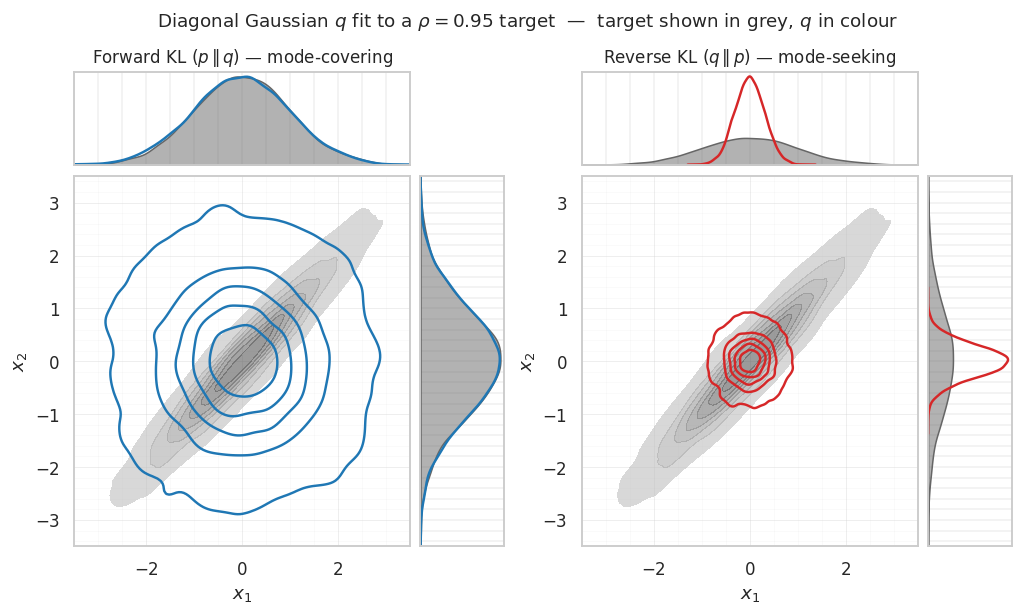

In [8]:
# Joint + marginal view via seaborn KDEs — the differences live in the marginals.
import matplotlib.gridspec as gs
import seaborn as sns

sns.set_theme(style="whitegrid")
# seaborn's theme overrides our rcParams — re-apply the minor-grid bits.
plt.rcParams.update({
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.3,
})

N_VIS = 8000
key_p, key_f, key_r = jax.random.split(jax.random.PRNGKey(42), 3)
samples_p   = np.asarray(target.sample(key_p, (N_VIS,)))
samples_fwd = np.asarray(jax.random.normal(key_f, (N_VIS, 2))) * np.asarray(s_fwd) + np.asarray(m_fwd)
samples_rev = np.asarray(jax.random.normal(key_r, (N_VIS, 2))) * np.asarray(s_rev) + np.asarray(m_rev)

LIM = (-3.5, 3.5)

def joint_panel(fig, outer, samples_target, samples_q, color_q, title):
    """Build a 2x2 gridspec inside ``outer``: top + right marginals around a central joint."""
    inner = gs.GridSpecFromSubplotSpec(
        2, 2, subplot_spec=outer,
        width_ratios=[4, 1], height_ratios=[1, 4],
        wspace=0.05, hspace=0.05,
    )
    ax_top   = fig.add_subplot(inner[0, 0])
    ax_main  = fig.add_subplot(inner[1, 0])
    ax_right = fig.add_subplot(inner[1, 1])

    # central joint: target as filled grey KDE, q overlaid as coloured outlines
    sns.kdeplot(x=samples_target[:, 0], y=samples_target[:, 1],
                ax=ax_main, fill=True, levels=8,
                color="0.4", alpha=0.6, thresh=0.02)
    sns.kdeplot(x=samples_q[:, 0], y=samples_q[:, 1],
                ax=ax_main, fill=False, levels=6,
                color=color_q, linewidths=1.6, thresh=0.02)
    ax_main.set_xlim(*LIM); ax_main.set_ylim(*LIM)
    ax_main.set_xlabel(r"$x_1$"); ax_main.set_ylabel(r"$x_2$")
    ax_main.minorticks_on()
    ax_main.grid(True, which="major", alpha=0.35, lw=0.6)
    ax_main.grid(True, which="minor", alpha=0.15, lw=0.4)

    # top marginal — x_1
    sns.kdeplot(x=samples_target[:, 0], ax=ax_top, color="0.4", fill=True, alpha=0.5)
    sns.kdeplot(x=samples_q[:, 0],      ax=ax_top, color=color_q, lw=1.6)
    ax_top.set_xlim(*LIM); ax_top.set_yticks([])
    ax_top.set_xticklabels([]); ax_top.set_xlabel(""); ax_top.set_ylabel("")
    ax_top.set_title(title, fontsize=11)

    # right marginal — x_2
    sns.kdeplot(y=samples_target[:, 1], ax=ax_right, color="0.4", fill=True, alpha=0.5)
    sns.kdeplot(y=samples_q[:, 1],      ax=ax_right, color=color_q, lw=1.6)
    ax_right.set_ylim(*LIM); ax_right.set_xticks([])
    ax_right.set_yticklabels([]); ax_right.set_xlabel(""); ax_right.set_ylabel("")


fig = plt.figure(figsize=(11, 5.6))
outer = gs.GridSpec(1, 2, figure=fig, wspace=0.18, top=0.88)

joint_panel(fig, outer[0, 0], samples_p, samples_fwd,
            color_q="#1f77b4",
            title=r"Forward KL $(p\,\Vert\,q)$ — mode-covering")
joint_panel(fig, outer[0, 1], samples_p, samples_rev,
            color_q="#d62728",
            title=r"Reverse KL $(q\,\Vert\,p)$ — mode-seeking")

fig.suptitle(r"Diagonal Gaussian $q$ fit to a $\rho = 0.95$ target  —  "
             r"target shown in grey, $q$ in colour",
             fontsize=12, y=0.98)
plt.show()


:::{warning}
Direction matters. Reverse KL is the default in ELBO-based VI because it gives a tractable lower bound on the marginal likelihood. The price is the mode-seeking pathology you see on the right — variance under-estimation, especially under multi-modality. This is exactly what α-divergence and expectation-propagation methods try to ameliorate.
:::

## 7. The `kl_standard_normal` shortcut

:::{tip} ELI5
**When you constrain $q$ to be standard-normal $\mathcal{N}(\mathbf{0}, \mathbf{I})$, the KL formula collapses to something almost trivial.** This case is everywhere — VAEs, SVGPs in the whitened parameterisation, last-layer Bayesian NNs, normalising-flow priors. It's worth knowing the simplified form by heart.
:::

**What it is.** A specialisation of equation [](#eq:kl-gaussian) when $q = \mathcal{N}(\mathbf{0}, \mathbf{I})$. The cross-terms vanish: $\boldsymbol{\Sigma}_q^{-1} = \mathbf{I}$, $\boldsymbol{\mu}_q = \mathbf{0}$, $\log\lvert\boldsymbol{\Sigma}_q\rvert = 0$.

**Continuous form.**

$$ \mathrm{KL}\!\bigl(\mathcal{N}(\mathbf{m}, \boldsymbol{\Sigma}) \,\Vert\, \mathcal{N}(\mathbf{0}, \mathbf{I})\bigr) = \tfrac{1}{2}\bigl[\mathrm{tr}(\boldsymbol{\Sigma}) + \mathbf{m}^\top\mathbf{m} - d - \log\lvert\boldsymbol{\Sigma}\rvert\bigr]. $$ (eq:kl-standard)

**Numerical recipe.** For diagonal $\boldsymbol{\Sigma} = \mathrm{diag}(\sigma_1^2, \dots, \sigma_d^2)$ equation [](#eq:kl-standard) further specialises to

$$ \mathrm{KL} = \tfrac{1}{2}\sum_i \bigl(\sigma_i^2 + m_i^2 - 1 - \log\sigma_i^2\bigr), $$ (eq:kl-standard-diag)

which is the per-coordinate formula you'll see hard-coded in 90% of ELBO implementations.

**Interpretation & where it shows up.**

- **VAE prior regulariser.** The KL term in the standard VAE loss is exactly equation [](#eq:kl-standard-diag) summed across latent dimensions and batched across data points.
- **Whitening.** SVGP and Bayesian NN methods often *change variables* to make the prior $\mathcal{N}(\mathbf{0}, \mathbf{I})$ — every KL becomes equation [](#eq:kl-standard) and stays cheap.
- **Easy gradients.** The diagonal form [](#eq:kl-standard-diag) is per-coordinate and trivially differentiable, which is why mean-field variational families default to this parameterisation. Compare to the full equation [](#eq:kl-gaussian), where the Cholesky of $\boldsymbol{\Sigma}_q$ shows up in every gradient.

In [9]:
m = jnp.array([0.5, -0.25])
S_diag = jnp.array([[0.6, 0.0],
                    [0.0, 1.4]])
S = psd_op(S_diag)
I_d = psd_op(jnp.eye(2))

# (a) gaussx shortcut.
KL_short = float(kl_standard_normal(m, S))

# (b) general routine via dist_kl_divergence.
KL_full = float(dist_kl_divergence(m, S, jnp.zeros(2), I_d))

# (c) hand-rolled diagonal formula via einx.
sigma2 = jnp.diag(S_diag)
KL_diag = 0.5 * float(einx.sum("i ->", sigma2 + m * m - 1.0 - jnp.log(sigma2)))

print(f"kl_standard_normal       : {KL_short:.6f}")
print(f"dist_kl_divergence vs N(0,I): {KL_full:.6f}")
print(f"hand-rolled diagonal     : {KL_diag:.6f}")


kl_standard_normal       : 0.243427
dist_kl_divergence vs N(0,I): 0.243427
hand-rolled diagonal     : 0.243427


## 8. Expected log-likelihood under a Gaussian

:::{tip} ELI5
**You don't always know the latent $\mathbf{f}$ exactly — you have a *distribution* over it. The expected log-likelihood is what you'd get if you averaged the log-likelihood over that uncertainty.** For Gaussians it picks up an extra term: a penalty proportional to *your uncertainty*. The more uncertain you are about $\mathbf{f}$, the worse your expected fit, even if your mean is right.
:::

**What it is.** When the latent variable $\mathbf{f}$ is itself uncertain (described by a Gaussian variational posterior $q(\mathbf{f}) = \mathcal{N}(\boldsymbol{\mu}_q, \boldsymbol{\Sigma}_q)$), and the observation model is Gaussian $p(\mathbf{y}\mid\mathbf{f}) = \mathcal{N}(\mathbf{f}, \mathbf{R})$, the data-fit term of the ELBO has a closed form that decomposes into "log-density at the mean" plus a "trace correction" for posterior uncertainty.

**Continuous form.**

$$ \mathbb{E}_q[\log p(\mathbf{y}\mid\mathbf{f})] = -\tfrac{m}{2}\log 2\pi - \tfrac{1}{2}\log\lvert\mathbf{R}\rvert - \tfrac{1}{2}(\mathbf{y}-\boldsymbol{\mu}_q)^\top\mathbf{R}^{-1}(\mathbf{y}-\boldsymbol{\mu}_q) - \tfrac{1}{2}\mathrm{tr}(\mathbf{R}^{-1}\boldsymbol{\Sigma}_q). $$ (eq:ell)

The first three terms are just the log-density of a Gaussian (cf. [0.1 §1](multivariate_gaussian.ipynb)) evaluated at the posterior *mean*. The fourth — the **trace correction** $\tfrac{1}{2}\mathrm{tr}(\mathbf{R}^{-1}\boldsymbol{\Sigma}_q)$ — is new.

**Numerical recipe.** All four terms reuse the same Cholesky of $\mathbf{R}$:

$$ \mathbb{E}_q[\log p(\mathbf{y}\mid\mathbf{f})] = \log\mathcal{N}(\mathbf{y}; \boldsymbol{\mu}_q, \mathbf{R}) - \tfrac{1}{2}\mathrm{tr}(\mathbf{R}^{-1}\boldsymbol{\Sigma}_q). $$ (eq:ell-decomposed)

The trace can be written $\mathrm{tr}(\mathbf{L}_R^{-1}\boldsymbol{\Sigma}_q\mathbf{L}_R^{-\top})$ with $\mathbf{R} = \mathbf{L}_R\mathbf{L}_R^\top$, sharing factors with [](#eq:quad-form-cholesky) and [](#eq:entropy-cholesky).

**Interpretation & where it shows up.**

- **Trace correction = "uncertainty tax".** It vanishes as $\boldsymbol{\Sigma}_q\to\mathbf{0}$ (deterministic limit) and grows as $\boldsymbol{\Sigma}_q$ inflates. So an over-confident $q$ — small $\boldsymbol{\Sigma}_q$ — has a small ELL penalty but pays through the KL term [](#eq:kl-gaussian); an over-spread $q$ is the opposite. Balancing the two is what variational fitting does.
- **SVGP / VGP / Bayesian NN ELBOs.** Every Gaussian-likelihood variational ELBO has equation [](#eq:ell) (or its sum across data points) as its data-fit term.
- **Conjugate identity.** When $q$ equals the *true* Gaussian-conjugate posterior, equation [](#eq:ell) plus the prior KL [](#eq:kl-gaussian) collapses to $\log p(\mathbf{y})$ — the marginal likelihood of the data. We see this concretely in §10.

`gaussx.gaussian_expected_log_lik(y, q_mu, q_cov, noise)` evaluates equation [](#eq:ell) directly.

In [10]:
# Mock data: 3-dim observation y, latent f ~ N(q_mu, q_cov), noise R.
y = jnp.array([1.0, 0.5, -0.3])
q_mu_f = jnp.array([0.9, 0.6, -0.2])
q_cov_f = psd_op(0.05 * jnp.eye(3) + 0.02)
R = psd_op(0.1 * jnp.eye(3))

ELL_gx = float(gaussian_expected_log_lik(y, q_mu_f, q_cov_f, R))

# Closed-form check term-by-term, written with einx.
m_obs = y.shape[0]
delta_y = y - q_mu_f
R_dense = R.as_matrix()
quad_term = float(quadratic_form(R, delta_y))
trace_term = float(jnp.trace(jnp.linalg.solve(R_dense, q_cov_f.as_matrix())))
_, logdet_R = jnp.linalg.slogdet(R_dense)
ELL_manual = -0.5 * m_obs * jnp.log(2 * jnp.pi) - 0.5 * logdet_R \
             - 0.5 * quad_term - 0.5 * trace_term

# Monte-Carlo cross-check.
key = jax.random.PRNGKey(123)
q_dist = MultivariateNormal(q_mu_f, q_cov_f)
f_samples = q_dist.sample(key, (50_000,))
def loglik(f):
    return gaussian_log_prob(f, R, y)
ELL_mc = float(jnp.mean(jax.vmap(loglik)(f_samples)))

print(f"ELL (gaussx primitive)   : {ELL_gx:.6f}")
print(f"ELL (manual closed form) : {float(ELL_manual):.6f}")
print(f"ELL (MC, 50k samples)    : {ELL_mc:.6f}")


ELL (gaussx primitive)   : -0.502938
ELL (manual closed form) : -0.502938
ELL (MC, 50k samples)    : -0.500431


## 9. Mutual information between blocks

:::{tip} ELI5
**How much does knowing one part of $\mathbf{x}$ tell you about the other?** Zero if they're independent. Maximal if knowing $X_b$ pins down $X_a$ exactly. For Gaussians it has a clean closed form involving only determinants of $\boldsymbol{\Sigma}$ and its diagonal blocks.
:::

**What it is.** Mutual information $I(X_a; X_b) = H(X_a) + H(X_b) - H(X_a, X_b)$ measures the reduction in uncertainty about $X_a$ obtained by observing $X_b$ (and vice versa — it's symmetric, despite KL not being). For Gaussians the entropies all simplify via equation [](#eq:entropy), leaving a ratio of log-determinants.

**Continuous form.** Partition $\mathbf{x} = (\mathbf{x}_a, \mathbf{x}_b)$ as in [0.1 §4](multivariate_gaussian.ipynb#eq:mvn-partition). Substituting equation [](#eq:entropy) for each entropy term and cancelling the additive constants:

$$ I(X_a; X_b) = \tfrac{1}{2}\log\!\frac{\lvert\boldsymbol{\Sigma}_{aa}\rvert\,\lvert\boldsymbol{\Sigma}_{bb}\rvert}{\lvert\boldsymbol{\Sigma}\rvert}. $$ (eq:mi)

**Numerical recipe.** Three log-determinants, no quadratic forms — equation [](#eq:mi) is computed entirely from Cholesky factors of $\boldsymbol{\Sigma}_{aa}$, $\boldsymbol{\Sigma}_{bb}$, and the joint $\boldsymbol{\Sigma}$. For the 2D case with correlation $\rho$ it collapses to

$$ I(X_a; X_b) = -\tfrac{1}{2}\log(1 - \rho^2), $$ (eq:mi-2d)

a recovery of the classical information-theoretic measure of correlation strength.

**Interpretation & where it shows up.**

- **Conditional independence.** $I(X_a; X_b) = 0$ iff $\boldsymbol{\Sigma}_{ab} = \mathbf{0}$, in which case the joint factorises as the product of marginals. Equation [](#eq:mi) is therefore a quantitative diagnostic for *how strongly* two blocks interact — exactly the question Gaussian graphical models try to answer.
- **Sensor placement / experimental design.** Choose observations $\mathbf{x}_b$ that maximise $I$ with the quantity of interest $\mathbf{x}_a$ — equivalently, that shrink the determinant of the conditional covariance via the Schur identity from [0.1 §5](multivariate_gaussian.ipynb).
- **Bayesian active learning.** Predictive entropy search and BALD use equation [](#eq:mi) (often with a non-Gaussian likelihood, but Gaussian-approximated) to score candidate queries.
- **Information bottleneck.** The IB objective is a difference of MI terms; for Gaussian-process variants both pieces have closed forms via [](#eq:mi).

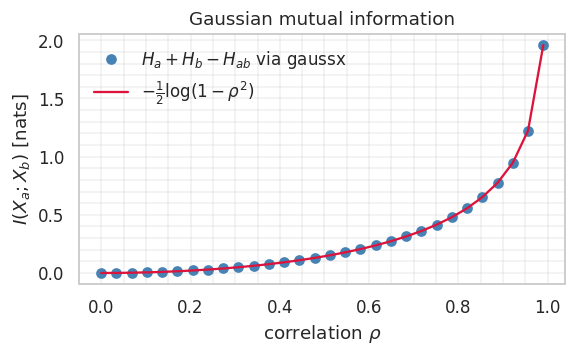

In [11]:
rhos = jnp.linspace(0.0, 0.99, 30)

def mi_2d(rho: float) -> float:
    Sigma = jnp.array([[1.0, rho], [rho, 1.0]])
    Sigma_aa = psd_op(Sigma[:1, :1])
    Sigma_bb = psd_op(Sigma[1:, 1:])
    Sigma_full = psd_op(Sigma)
    H_aa = float(gaussian_entropy(Sigma_aa))
    H_bb = float(gaussian_entropy(Sigma_bb))
    H_full = float(gaussian_entropy(Sigma_full))
    return H_aa + H_bb - H_full

mi_vals = jnp.array([mi_2d(float(r)) for r in rhos])
mi_closed = -0.5 * jnp.log(1.0 - rhos ** 2)

fig, ax = plt.subplots(figsize=(5.4, 3.4))
ax.plot(np.asarray(rhos), np.asarray(mi_vals), "o", label=r"$H_a + H_b - H_{ab}$ via gaussx", color="steelblue")
ax.plot(np.asarray(rhos), np.asarray(mi_closed), "-", label=r"$-\frac{1}{2}\log(1-\rho^2)$", color="crimson")
ax.set_xlabel(r"correlation $\rho$"); ax.set_ylabel(r"$I(X_a; X_b)$ [nats]")
ax.set_title("Gaussian mutual information")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()


## 10. Putting it together: a one-step ELBO

:::{tip} ELI5
**The ELBO is a tractable lower bound on $\log p(\mathbf{y})$ — a number that's easy to compute and easy to maximise to fit your model.** For Gaussian likelihoods + Gaussian variational posteriors, every piece of it is a closed form from this notebook. No Monte Carlo. No quadrature. Just Cholesky.
:::

**What it is.** The Evidence Lower BOund (ELBO) is the workhorse of variational inference. It decomposes as data-fit minus prior penalty: the expected log-likelihood [](#eq:ell) of the data under $q$, minus the KL [](#eq:kl-gaussian) between $q$ and the prior.

**Continuous form.**

$$ \mathrm{ELBO}(q) = \underbrace{\mathbb{E}_q[\log p(\mathbf{y}\mid\mathbf{f})]}_{\text{data fit}} \;-\; \underbrace{\mathrm{KL}\!\bigl(q(\mathbf{f}) \,\Vert\, p(\mathbf{f})\bigr)}_{\text{prior penalty}}. $$ (eq:elbo)

**Numerical recipe.** Plug equation [](#eq:ell) and equation [](#eq:kl-gaussian) into [](#eq:elbo). Both pieces share Cholesky factors with everything in this notebook. For the toy below we sweep $q$'s mean over a grid; in real use you'd differentiate the ELBO and run gradient ascent — every term in the gradient is also closed-form.

**Interpretation.**

- **Variational identity.** $\log p(\mathbf{y}) - \mathrm{ELBO}(q) = \mathrm{KL}(q\Vert p_{\text{post}}) \ge 0$, with equality iff $q$ equals the true posterior. Maximising the ELBO over $q$ minimises the variational gap.
- **Conjugate sanity check.** For Gaussian-Gaussian conjugate models, the optimum $q$ *is* the true posterior, and the ELBO equals $\log p(\mathbf{y})$ exactly. The toy below illustrates this: the ELBO peak lands on the conjugate posterior mean.
- **Scales linearly.** Add data points → sum more `gaussian_expected_log_lik` terms; add latent dimensions → bigger Cholesky. No new closed forms ever needed.

true posterior     : N(0.7273, 0.0909)


argmax ELBO over m : 0.7288


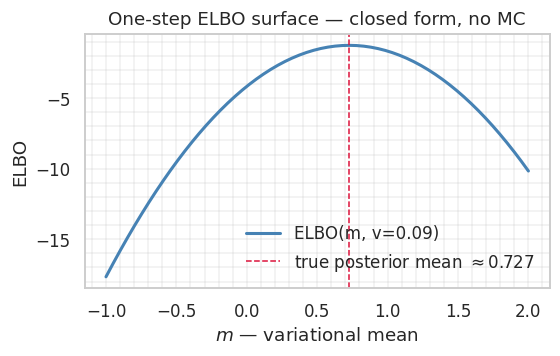

In [12]:
y_obs = jnp.array([0.8])
prior_mu = jnp.zeros(1)
prior_cov = psd_op(jnp.eye(1))
noise = psd_op(0.1 * jnp.eye(1))

def elbo(q_m: float, q_v: float) -> float:
    q_mu_arr = jnp.array([q_m])
    q_cov = psd_op(q_v * jnp.eye(1))
    ell = gaussian_expected_log_lik(y_obs, q_mu_arr, q_cov, noise)
    kl = dist_kl_divergence(q_mu_arr, q_cov, prior_mu, prior_cov)
    return float(ell - kl)

q_means = jnp.linspace(-1.0, 2.0, 60)
q_var = 0.09
elbos = jnp.array([elbo(float(m), q_var) for m in q_means])

# True posterior mean for a Gaussian-Gaussian conjugate pair (closed form).
post_var = 1.0 / (1.0 / 1.0 + 1.0 / 0.1)
post_mean = post_var * (0.0 / 1.0 + 0.8 / 0.1)
print(f"true posterior     : N({post_mean:.4f}, {post_var:.4f})")
print(f"argmax ELBO over m : {float(q_means[jnp.argmax(elbos)]):.4f}")

fig, ax = plt.subplots(figsize=(5.4, 3.4))
ax.plot(np.asarray(q_means), np.asarray(elbos), color="steelblue", lw=2, label="ELBO(m, v=0.09)")
ax.axvline(post_mean, color="crimson", ls="--", lw=1, label=fr"true posterior mean $\approx {post_mean:.3f}$")
ax.set_xlabel(r"$m$ — variational mean"); ax.set_ylabel("ELBO")
ax.set_title("One-step ELBO surface — closed form, no MC")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()


:::{seealso}
This is a one-equation toy, but the structure scales: every SVGP, every Bayesian NN with Gaussian last-layer, every Kalman variational filter is built from the same two closed forms — `gaussian_expected_log_lik` and `dist_kl_divergence` — possibly summed over data points or time steps. See [Part 5 — Approximations](../05_approximations/) for the full treatment.
:::

## 11. Recap & where to go next

| Quantity                   | Continuous form (equation)    | Numerical (equation)               | gaussx entry point             |
|----------------------------|-------------------------------|------------------------------------|--------------------------------|
| Quadratic form             | [](#eq:quad-form)             | [](#eq:quad-form-cholesky)         | `quadratic_form`               |
| Score                      | [](#eq:score)                 | [](#eq:score-solve)                | `solve` (or `jax.grad` of `gaussian_log_prob`) |
| Entropy                    | [](#eq:entropy)               | [](#eq:entropy-cholesky)           | `gaussian_entropy`             |
| Cross-entropy              | [](#eq:cross-entropy-gaussian)| via identity [](#eq:kl-identity)   | $H(p) + \mathrm{KL}(p\Vert q)$ |
| KL divergence              | [](#eq:kl-gaussian)           | reuses Cholesky factors            | `dist_kl_divergence`           |
| KL vs $\mathcal{N}(0,I)$   | [](#eq:kl-standard)           | diagonal: [](#eq:kl-standard-diag) | `kl_standard_normal`           |
| Expected log-likelihood    | [](#eq:ell)                   | [](#eq:ell-decomposed)             | `gaussian_expected_log_lik`    |
| Mutual information         | [](#eq:mi)                    | 2D special case [](#eq:mi-2d)      | sum of `gaussian_entropy` calls |
| ELBO                       | [](#eq:elbo)                  | ELL − KL                           | combine the two above          |

**Next up.**
- [0.4 — Mean-cov ↔ natural parameter conversions](exponential_family.ipynb): the third equivalent representation, plus `log_partition`, `fisher_info`, and the Bregman view of KL.
- [0.7 — Conditional distributions & Schur complement](conditional_distributions.ipynb): full treatment of Gaussian conditioning.
- [Part 5 — Variational approximations](../05_approximations/): where these closed forms are summed over data to give the SVGP / VGP / variational Bayes machinery.